In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.dates as mdates
from IPython.display import Image
import sys

sys.path.append('/g/data/ng72/ab4502/hot-cloudy/modules/')
from case_study_utils import *

In [2]:
#Load temperature data for high/low demand days from Alex
temps, temps_low = load_demand_data()

#Load solar CF data from Carl
cloud = load_cloud()

#Load Carl's previous dataset
cloud_orig = load_cloud_gccsa()

In [3]:
#Subset solar CF data to Brisbane, between 6 am and 9 pm, during Nov-Apr
cloud = cloud.sel(region="GBRI",time=(cloud.time.dt.hour>=6) & (cloud.time.dt.hour<=21) & (np.in1d(cloud.time.dt.month,[11,12,1,2,3,4])))

In [4]:
#Resample capacity factors to daily mean, and calculate clear sky index
daily_cloud = cloud.groupby("time.date").mean()
daily_csi = daily_cloud.actual / daily_cloud.ideal

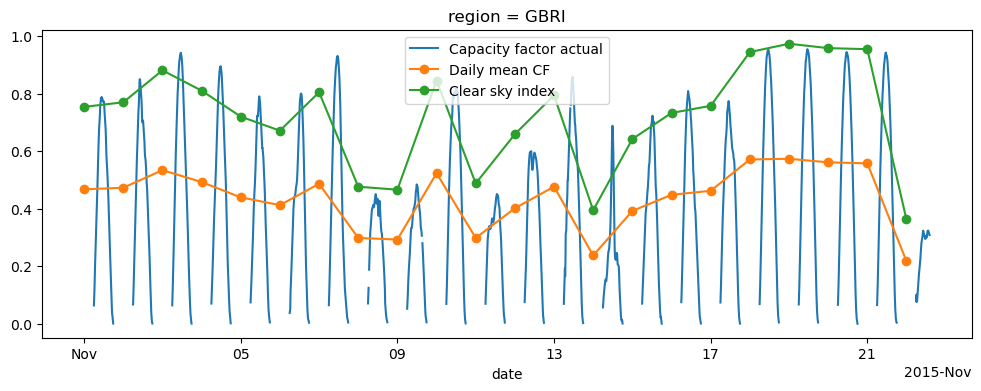

In [5]:
#Plot for a month or so to make sure everything is fine

plt.figure(figsize=[12,4])

cloud.isel(time=slice(0,2000)).actual.plot(label="Capacity factor actual")

daily_cloud.actual.isel(date=slice(0,22)).plot(marker="o",label="Daily mean CF")
daily_csi.isel(date=slice(0,22)).plot(marker="o",label="Clear sky index")

plt.legend()

<Axes: >

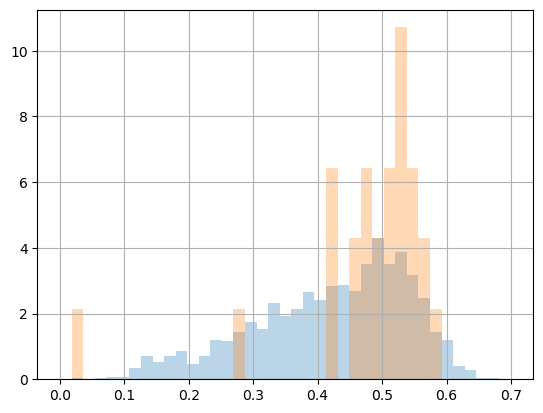

In [6]:
#Look at normalised occurrence frequency plot

daily_cloud.actual.to_pandas().hist(density=True,alpha=0.3,bins=np.linspace(0,0.7,40))
daily_cloud.sel(date=temps.sel(region="QLD").dropna("time").time).actual.to_pandas().hist(density=True,alpha=0.3,bins=np.linspace(0,0.7,40))

In [7]:
#Combine the temperature and solar CF datset
merged = pd.merge(
    temps.sel(region="QLD").tasmax.dropna("time").to_pandas(),
    daily_cloud.sel(date=temps.sel(region="QLD").dropna("time").time).actual.to_pandas(),
    left_index=True,
    right_index=True).sort_values("actual")

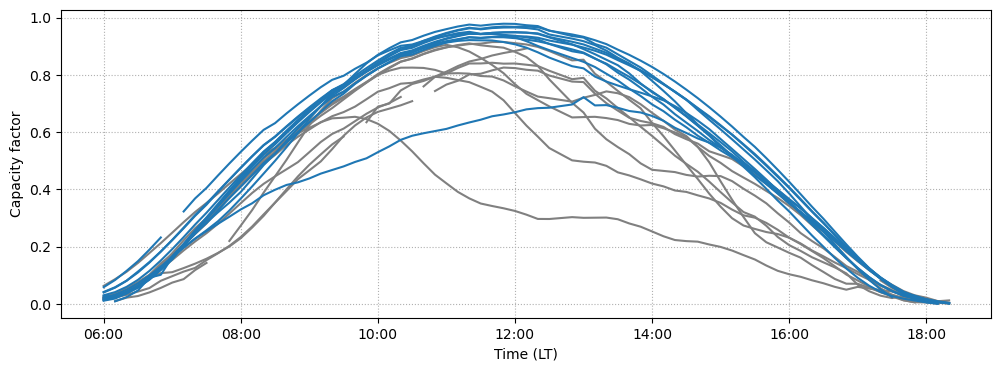

In [8]:
#Plot the top 10 cloudies and top 10 clearest (hot, high demand) days in terms of CF

cloudy_dates = pd.to_datetime(merged.index[0:10]).date

clear_dates = pd.to_datetime(merged.index[-10:]).date

times = cloud.sel(time=np.in1d(cloud.time.dt.date,clear_dates[0])).time


plt.figure(figsize=[12,4])


[plt.plot(times,cloud.sel(time=cloud.time.dt.date ==d).actual.values,color="grey") for d in cloudy_dates]
[plt.plot(times,cloud.sel(time=cloud.time.dt.date ==d).actual.values,color="tab:blue") for d in clear_dates]

plt.plot(times,cloud.sel(time=cloud.time.dt.date == dt.date(2020,1,30)).actual.values)


myFmt = mdates.DateFormatter('%H:%M')
plt.gca().xaxis.set_major_formatter(myFmt)

plt.xlabel("Time (LT)")
plt.ylabel("Capacity factor")

plt.gca().grid(ls=":")

In [9]:
#Load the AEMO demand data
demand = load_nemosis("/g/data/gb02/dr6273/work/data/AEMO/processed/NEM_DISPATCHREGIONSUM_5min_20090701-20231231.csv")["QLD"]

In [10]:
#Load station data for Brisbane airport
stn_data = load_stn_data("QLD",40842,temps.time.values.min(),temps.time.values.max())

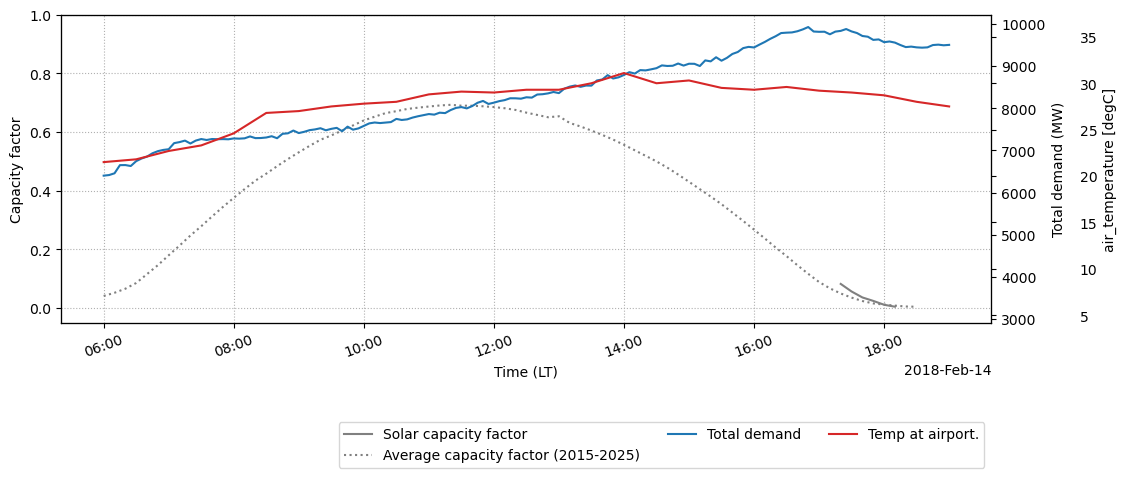

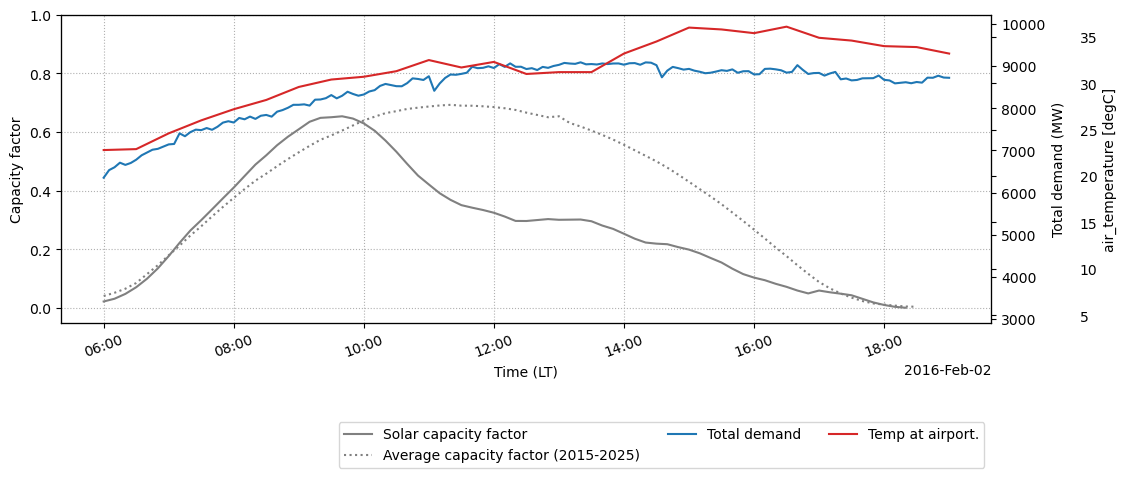

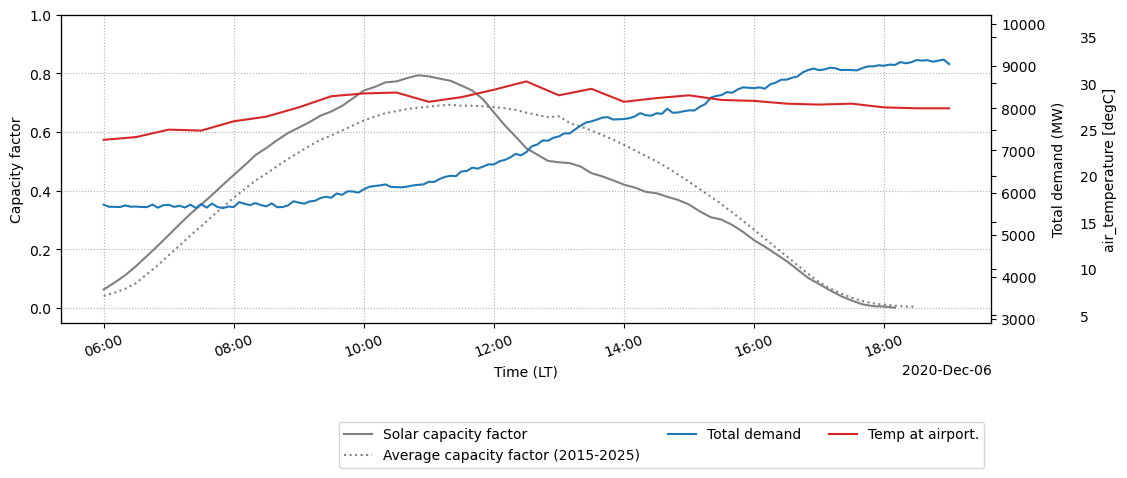

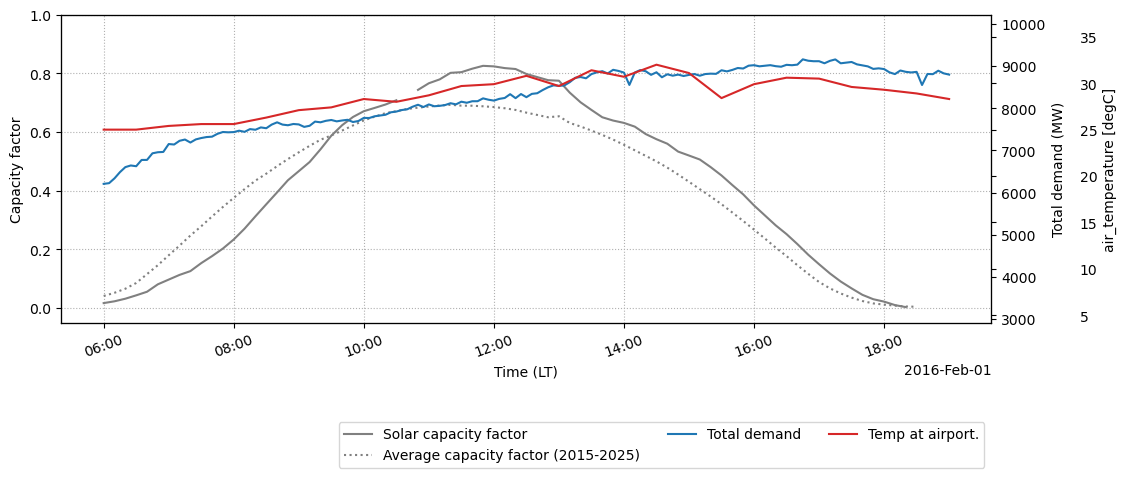

In [11]:
#Plot time series for some interesting days
plot_ts(
    cloudy_dates[0],
    cloud,
    demand,
    stn_data,
    pd.to_datetime(cloudy_dates[0]).replace(hour=6),
    pd.to_datetime(cloudy_dates[0]).replace(hour=19))

plot_ts(
    cloudy_dates[1],
    cloud,
    demand,
    stn_data,
    pd.to_datetime(cloudy_dates[1]).replace(hour=6),
    pd.to_datetime(cloudy_dates[1]).replace(hour=19))

plot_ts(
    cloudy_dates[2],
    cloud,
    demand,
    stn_data,
    pd.to_datetime(cloudy_dates[2]).replace(hour=6),
    pd.to_datetime(cloudy_dates[2]).replace(hour=19))

plot_ts(
    cloudy_dates[3],
    cloud,
    demand,
    stn_data,
    pd.to_datetime(cloudy_dates[3]).replace(hour=6),
    pd.to_datetime(cloudy_dates[3]).replace(hour=19))

https://www.australianweathernews.com/archives/mslanal/2016/16020206.gif


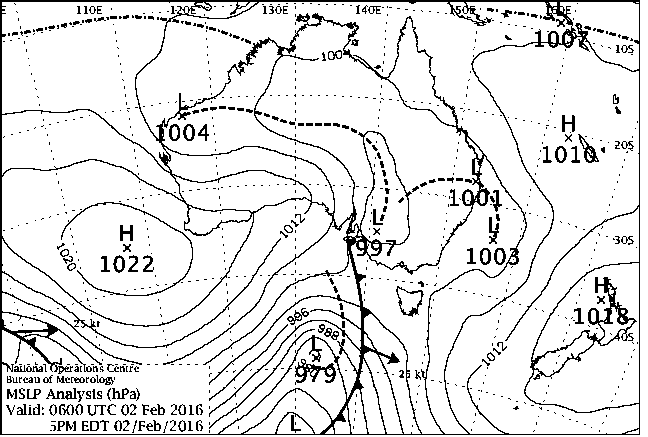

In [12]:
#From https://www.australianweathernews.com/index.shtml

plot_ausweathernews_mslp(cloudy_dates[1])

https://www.australianweathernews.com/archives/mslanal/2020/20120606.gif


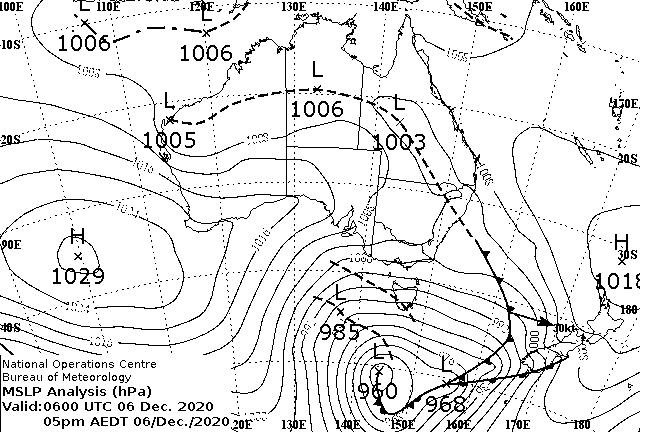

In [13]:
plot_ausweathernews_mslp(cloudy_dates[2])

In [14]:
plot_ausweathernews_mslp(cloudy_dates[3])

https://www.australianweathernews.com/archives/mslanal/2016/16020106.gif
MSLP not available


https://www.australianweathernews.com/archives/satellite/BoM--irenh/2016/IDE00035.201602020530.jpg


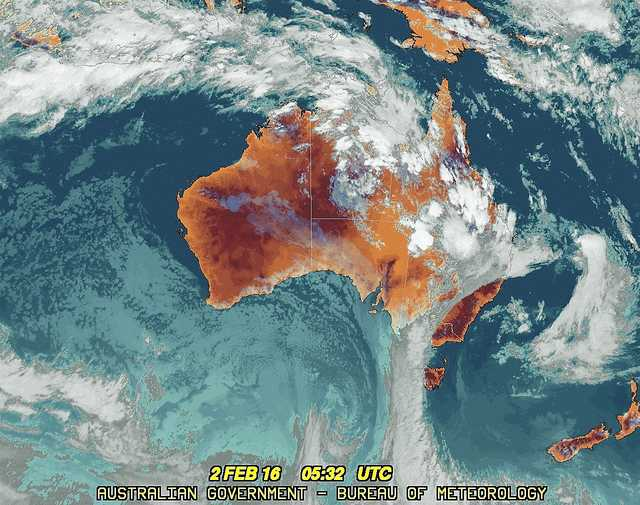

In [15]:
plot_ausweathernews_sat(cloudy_dates[1])

https://www.australianweathernews.com/archives/satellite/BoM--irenh/2020/IDE00134.202012060530.jpg


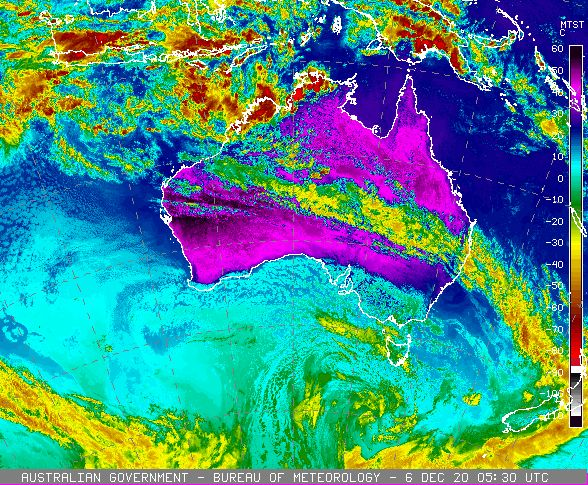

In [16]:
plot_ausweathernews_sat(cloudy_dates[2])

In [17]:
plot_ausweathernews_sat(cloudy_dates[3])

https://www.australianweathernews.com/archives/satellite/BoM--irenh/2016/IDE00035.201602010530.jpg
Satellite not available
